In [1]:
%pip install pandas numpy openpyxl matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Packages imported successfully.")

Packages imported successfully.


In [3]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    BASE_DIR = NOTEBOOK_DIR.parent
else:
    BASE_DIR = Path(r"C:\GEO_Breast_Reliability")

DATA_DIR = BASE_DIR / "GSE81538"
PROCESSED_DIR = BASE_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", BASE_DIR)
print("Data directory:", DATA_DIR)

Notebook directory: C:\GEO_Breast_Reliability
Project directory: C:\GEO_Breast_Reliability
Data directory: C:\GEO_Breast_Reliability\GSE81538


In [4]:
expression_file = (
    DATA_DIR
    / "GSE81538_gene_expression_405_transformed.csv.gz"
)

pathology_file = (
    DATA_DIR
    / "GSE81538_pathology_consensus_key.xlsx"
)

mapping_file = (
    DATA_DIR
    / "GSE81538_map_transcriptID_geneSymbol.csv.gz"
)

files = {
    "Expression": expression_file,
    "Pathology": pathology_file,
    "Gene mapping": mapping_file,
}

for label, file_path in files.items():
    print(f"{label}:")
    print(f"  Path: {file_path}")
    print(f"  Exists: {file_path.exists()}")

Expression:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_gene_expression_405_transformed.csv.gz
  Exists: True
Pathology:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_pathology_consensus_key.xlsx
  Exists: True
Gene mapping:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_map_transcriptID_geneSymbol.csv.gz
  Exists: True


In [5]:
expression = pd.read_csv(
    expression_file,
    compression="gzip",
    low_memory=False,
)

pathology = pd.read_excel(
    pathology_file,
    engine="openpyxl",
)

gene_mapping = pd.read_csv(
    mapping_file,
    compression="gzip",
    low_memory=False,
)

print("Expression shape:", expression.shape)
print("Pathology shape:", pathology.shape)
print("Gene mapping shape:", gene_mapping.shape)

Expression shape: (18802, 406)
Pathology shape: (47, 3)
Gene mapping shape: (80883, 1)


In [6]:
print("Expression columns:")
print(expression.columns.tolist()[:20])

print("\nPathology columns:")
print(pathology.columns.tolist())

print("\nGene-mapping columns:")
print(gene_mapping.columns.tolist())

Expression columns:
['Unnamed: 0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19']

Pathology columns:
['Key', 'Unnamed: 1', 'Unnamed: 2']

Gene-mapping columns:
['transcriptID\tgeneSymbol']


In [7]:
display(expression.head())
display(pathology.head())
display(gene_mapping.head())

,Unnamed: 0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20,T21,T22,T23,T24,T25,T26,T27,T28,T29,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39,T40,T41,T42,T43,T44,T45,T46,T47,T48,T49,...,T356,T357,T358,T359,T360,T361,T362,T363,T364,T365,T366,T367,T368,T369,T370,T371,T372,T373,T374,T375,T376,T377,T378,T379,T380,T381,T382,T383,T384,T385,T386,T387,T388,T389,T390,T391,T392,T393,T394,T395,T396,T397,T398,T399,T400,T401,T402,T403,T404,T405
0,A1BG,1.590427,0.782005,5.124489,3.537580,3.874691,2.272538,3.550594,3.136737,3.161802,3.151932,3.497633,1.961995,3.631561,3.544290,2.386028,1.843249,3.244755,2.188470,2.402527,0.795770,3.046153,1.991473,3.864399,3.899909,3.082804,1.706630,2.732762,2.624347,3.977895,0.980528,3.943785,3.616986,1.180831,4.668346,1.812331,2.791270,2.153686,-0.100649,2.179515,2.349054,4.365390,3.157309,2.893070,2.783516,3.907058,2.965861,3.801611,2.441532,1.773729,...,3.538586,4.391217,2.771130,3.911523,3.463763,3.266277,2.868520,2.473857,3.912993,2.828041,3.935869,4.510176,4.586879,1.519618,3.961982,3.617913,3.591158,3.233997,2.016215,3.178646,2.346388,2.788661,3.688376,3.218707,4.132225,5.297038,3.457067,2.780748,3.297015,3.589374,3.898516,3.512073,2.832179,2.741478,2.566608,2.877995,3.461101,3.378428,3.198886,4.120862,4.098176,3.495086,3.561725,4.623393,4.188254,2.779785,3.069689,1.135712,3.708821,3.045782
1,A1CF,-3.321928,-3.321928,-3.321928,-2.962358,-3.247635,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.196173,-3.321928,-3.321928,-3.157947,-2.987143,-3.321928,-3.321928,-2.999210,-3.321928,-3.321928,-3.079481,-3.321928,-2.922254,-3.268117,-3.228218,-3.321928,-3.321928,-3.050679,-3.180020,-3.321928,-3.321928,-3.321928,-3.321928,-3.271774,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.181339,-3.235205,-3.186652,-3.206183,-3.276338,-3.321928,-3.321928,-3.202082,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.046776,-3.265302,-3.268655,-3.321928,-3.321928,-3.321928,-3.213674,-3.321928,-3.321928,-3.205076,-3.101584,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.025040,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.266674,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.183435,-3.321928,-3.207230,-3.321928,-3.273963,-3.321928,-3.321928,-3.185844,-3.321928,-3.211343,-3.210499,-3.237576,-3.321928
2,A2LD1,1.484932,2.455667,1.707960,3.092352,2.755753,1.680052,2.708003,2.757847,1.372637,2.907377,1.610877,3.217761,1.597972,0.543120,1.583224,1.583045,2.766364,2.830138,3.056561,0.987064,2.432954,1.623032,2.890598,2.330526,3.386655,2.355278,2.405520,2.295722,2.431757,3.215258,4.087644,2.921802,2.208033,3.157157,3.088372,1.294471,2.730506,3.001961,0.640054,3.014846,2.188365,2.477252,2.713816,3.465105,1.940236,2.130217,2.761150,2.305201,1.853158,...,2.331627,2.463111,2.595263,2.024038,2.452407,1.830439,1.689191,1.498576,0.723199,3.199272,2.246286,3.385902,2.623776,3.083954,2.615226,2.150510,2.903736,1.494176,2.314816,2.276489,2.320858,3.081577,2.113725,1.763345,2.483315,1.467310,3.061397,2.615374,2.327495,1.310119,1.784152,1.646593,3.056123,2.005946,1.829687,2.231684,2.142627,1.919673,3.857979,2.441960,2.689509,1.886163,3.759563,2.857039,2.635550,2.202699,4.509565,2.616566,3.332391,2.114228
3,A2M,10.532488,4.758267,5.989012,7.436564,6.752650,6.035074,7.284499,5.581803,6.187325,7.423513,6.505761,7.254571,7.245814,7.215918,5.845969,5.679714,6.924969,7.065455,7.362096,6.913897,6.668096,6.830439,9.363927,5.340487,6.676673,7.034639,7.571163,7.927188,5.387430,6.814822,6.439756,7.189262,6.767210,6.204886,6.433237,6.973942,8.462191,6.931284,8.215213,5.329918,6.262659,6.474256,6.638012,5.237261,4.694713,6.675805,5.581680,6.835665,7.630627,...,7.073963,6.581579,8.113410,5.551198,7.499567,7.331103,7.391080,7.964124,6.334936,6.292682,6.768499,6.831067,6.232536,6.126733,6.911961,7.515414,6.839386,5.802571,6.201155,6.259618,7.056431,6.779820,7.520217,6.669916,6.285242,7.239861,8.193163,7.057198,7.911574,7.471170,6.158654,7.997474,

,Key,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,ER & PR,NaN,NaN
2,0,0,negative
3,1,1-10%,negative (Sweden) or positive (ASCO/CAP) depen...
4,2,11-50%,positive


,transcriptID\tgeneSymbol
0,uc001aaa.3\tDDX11L1
1,uc010nxr.1\tDDX11L1
2,uc010nxq.1\tDDX11L9
3,uc009vis.3\tWASH7P
4,uc009vjc.1\tWASH7P


In [8]:
# Rename the first column to gene_symbol
expression = expression.rename(
    columns={expression.columns[0]: "gene_symbol"}
)

# Set gene symbols as the row index
expression = expression.set_index("gene_symbol")

# Ensure all expression measurements are numeric
expression = expression.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Expression matrix shape:", expression.shape)
print("Number of genes:", expression.shape[0])
print("Number of samples:", expression.shape[1])
print("Missing expression values:", expression.isna().sum().sum())

display(expression.iloc[:5, :10])

Expression matrix shape: (18802, 405)
Number of genes: 18802
Number of samples: 405
Missing expression values: 0


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
gene_symbol,,,,,,,,,,
A1BG,1.590427,0.782005,5.124489,3.537580,3.874691,2.272538,3.550594,3.136737,3.161802,3.151932
A1CF,-3.321928,-3.321928,-3.321928,-2.962358,-3.247635,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
A2LD1,1.484932,2.455667,1.707960,3.092352,2.755753,1.680052,2.708003,2.757847,1.372637,2.907377
A2M,10.532488,4.758267,5.989012,7.436564,6.752650,6.035074,7.284499,5.581803,6.187325,7.423513
A2ML1,3.230358,3.831861,-3.081209,-2.008639,-2.755168,2.147659,-2.498165,-0.526405,-2.688875,-2.279001


In [9]:
%pip install GEOparse

Note: you may need to restart the kernel to use updated packages.


In [10]:
import GEOparse

gse = GEOparse.get_GEO(
    geo="GSE81538",
    destdir=str(DATA_DIR),
    annotate_gpl=False,
    silent=False
)

print("Number of GEO samples:", len(gse.gsms))

18-Jul-2026 12:37:27 DEBUG utils - Directory C:\GEO_Breast_Reliability\GSE81538 already exists. Skipping.
18-Jul-2026 12:37:27 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81538/soft/GSE81538_family.soft.gz to C:\GEO_Breast_Reliability\GSE81538\GSE81538_family.soft.gz
100%|██████████████████████████████████████████████████████████████████████████████| 49.8k/49.8k [00:00<00:00, 194kB/s]
18-Jul-2026 12:37:28 DEBUG downloader - Size validation passed
18-Jul-2026 12:37:28 DEBUG downloader - Moving C:\Users\kumia\AppData\Local\Temp\tmpqnn7dax8 to C:\GEO_Breast_Reliability\GSE81538\GSE81538_family.soft.gz
18-Jul-2026 12:37:28 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81538/soft/GSE81538_family.soft.gz
18-Jul-2026 12:37:28 INFO GEOparse - Parsing C:\GEO_Breast_Reliability\GSE81538\GSE81538_family.soft.gz: 
18-Jul-2026 12:37:28 DEBUG GEOparse - DATABASE: GeoMiame
18-Jul-2026 12:37:28 DEBUG GEOparse - SERIES: GS

Number of GEO samples: 405


In [11]:
import re
import pandas as pd


def clean_name(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


metadata_rows = []

for gsm_id, gsm in gse.gsms.items():
    row = {
        "gsm_id": gsm_id,
        "sample_id": gsm.metadata.get("title", [None])[0],
    }

    characteristics = gsm.metadata.get(
        "characteristics_ch1",
        []
    )

    for item in characteristics:
        if ":" not in item:
            continue

        key, value = item.split(":", 1)
        row[clean_name(key)] = value.strip()

    metadata_rows.append(row)

sample_metadata = pd.DataFrame(metadata_rows)

print("Metadata shape:", sample_metadata.shape)
display(sample_metadata.head())

Metadata shape: (405, 40)


,gsm_id,sample_id,tissue,er_ihc_routinestain_clinical_reading,er_ihc_routinestain_reading_2,er_ihc_routinestain_reading_3,er_ihc_restain_reading_1,er_ihc_restain_reading_2,er_ihc_restain_reading_3,er_consensus,pgr_ihc_routinestain_clinical_reading,pgr_routinestain_reading_2,pgr_routinestain_reading_3,pgr_restain_reading_1,pgr_restain_reading_2,pgr_restain_reading_3,pgr_consensus,her2_ihc_clinreading,her2_ihc_reading_2,her2_ihc_reading_3,her2_clinical_status,her2_sish_reading_1,her2_sish_reading_2,her2_sish_reading_3,her2_consensus,ki67_reading_1,ki67_reading_2,ki67_reading_3,ki67_consensus,nhg_reading_1_tubular,nhg_reading_1_pleomorph,nhg_reading_1_mitotic,nhg_reading_2_tubular,nhg_reading_2_pleomorph,nhg_reading_2_mitotic,nhg_reading_3_tubular,nhg_reading_3_pleomorph,nhg_reading_3_mitotic,nhg_consensus,pam50_subtype
0,GSM2155558,T1,breast tumor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,80,70,85,80,3,3,3,3,3,3,3,3,3,3,Basal
1,GSM2155559,T2,breast tumor,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,40,25,25,25,3,3,3,3,3,2,3,3,3,3,Her2
2,GSM2155560,T3,breast tumor,3,3,3,3,3,3,3,1,0,1,0,0,1,1,2,2,2,1,2,1,1,1,30,30,40,30,3,3,2,3,3,3,3,3,1,3,LumB
3,GSM2155561,T4,breast tumor,3,3,3,3,3,3,3,3,2,2,2,1,1,2,3,3,3,1,1,1,1,1,20,10,22,20,3,3,2,3,2,1,3,3,1,2,Her2
4,GSM2155562,T5,breast tumor,3,3,3,3,3,3,3,1,1,0,1,1,1,1,2,1,1,1,4,4,4,0,30,15,20,20,3,3,3,3,3,1,3,3,1,2,LumB


In [12]:
[column for column in sample_metadata.columns
 if "er" in column.lower()]

['er_ihc_routinestain_clinical_reading',
 'er_ihc_routinestain_reading_2',
 'er_ihc_routinestain_reading_3',
 'er_ihc_restain_reading_1',
 'er_ihc_restain_reading_2',
 'er_ihc_restain_reading_3',
 'er_consensus',
 'her2_ihc_clinreading',
 'her2_ihc_reading_2',
 'her2_ihc_reading_3',
 'her2_clinical_status',
 'her2_sish_reading_1',
 'her2_sish_reading_2',
 'her2_sish_reading_3',
 'her2_consensus']

In [13]:
sample_metadata["er_consensus"].value_counts(
    dropna=False
).sort_index()

er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64

In [14]:
display(
    sample_metadata[
        ["gsm_id", "sample_id", "er_consensus"]
    ].head(10)
)

,gsm_id,sample_id,er_consensus
0,GSM2155558,T1,0
1,GSM2155559,T2,0
2,GSM2155560,T3,3
3,GSM2155561,T4,3
4,GSM2155562,T5,3
5,GSM2155563,T6,0
6,GSM2155564,T7,3
7,GSM2155565,T8,0
8,GSM2155566,T9,3
9,GSM2155567,T10,0


In [15]:
sample_metadata["er_consensus"] = pd.to_numeric(
    sample_metadata["er_consensus"],
    errors="coerce"
)

er_counts = (
    sample_metadata["er_consensus"]
    .value_counts(dropna=False)
    .sort_index()
)

print("ER consensus counts:")
display(er_counts)

ER consensus counts:


er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64

In [16]:
pathology_key = pd.read_excel(
    pathology_file,
    header=None,
    engine="openpyxl"
)

print(
    pathology_key.to_string(
        index=False,
        header=False
    )
)

                              Key                                                                                                                                                                NaN                                                          NaN
                              NaN                                                                                                                                                                NaN                                                          NaN
                          ER & PR                                                                                                                                                                NaN                                                          NaN
                                0                                                                                                                                                                  0                              

In [17]:
# Convert the expression matrix to:
# samples as rows and genes as columns
X = expression.T.copy()

metadata_indexed = (
    sample_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

metadata_aligned = metadata_indexed.reindex(X.index)

print("Expression shape:", X.shape)
print("Metadata shape:", metadata_aligned.shape)

print(
    "Samples without matching metadata:",
    metadata_aligned["gsm_id"].isna().sum()
)

print(
    "Samples without ER consensus:",
    metadata_aligned["er_consensus"].isna().sum()
)

display(
    metadata_aligned[
        ["gsm_id", "er_consensus"]
    ].head(10)
)

Expression shape: (405, 18802)
Metadata shape: (405, 39)
Samples without matching metadata: 0
Samples without ER consensus: 0


,gsm_id,er_consensus
T1,GSM2155558,0
T2,GSM2155559,0
T3,GSM2155560,3
T4,GSM2155561,3
T5,GSM2155562,3
T6,GSM2155563,0
T7,GSM2155564,3
T8,GSM2155565,0
T9,GSM2155566,3
T10,GSM2155567,0


In [18]:
er_counts = (
    metadata_aligned["er_consensus"]
    .value_counts(dropna=False)
    .sort_index()
)

print("ER consensus category counts:")
print(er_counts)

ER consensus category counts:
er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64


In [19]:
X_sensitivity = X.copy()

y_sensitivity = (
    metadata_aligned["er_consensus"]
    .map({
        0: 0,
        1: 1,
        2: 1,
        3: 1
    })
    .astype(int)
)

print("Sensitivity-analysis shape:", X_sensitivity.shape)
print("\nSensitivity outcome counts:")
print(
    y_sensitivity.value_counts()
    .rename(index={0: "ER-negative", 1: "ER-positive"})
)

Sensitivity-analysis shape: (405, 18802)

Sensitivity outcome counts:
er_consensus
ER-positive    323
ER-negative     82
Name: count, dtype: int64


In [20]:
X_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_X_sensitivity_ER.pkl"
)

y_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_y_sensitivity_ER.pkl"
)

print("Sensitivity-analysis files saved.")

Sensitivity-analysis files saved.


In [23]:
# Recreate aligned expression and metadata
X = expression.T.copy()

metadata_indexed = (
    sample_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

metadata_aligned = metadata_indexed.reindex(X.index)

metadata_aligned["er_consensus"] = pd.to_numeric(
    metadata_aligned["er_consensus"],
    errors="coerce"
)

# Primary analysis:
# 0 = ER-negative
# 2 and 3 = ER-positive
# 1 = borderline and excluded
primary_mask = metadata_aligned["er_consensus"].isin([0, 2, 3])

X_primary = X.loc[primary_mask].copy()

y_primary = (
    metadata_aligned.loc[primary_mask, "er_consensus"]
    .map({
        0: 0,
        2: 1,
        3: 1
    })
    .astype(int)
)

primary_metadata = metadata_aligned.loc[primary_mask].copy()
primary_metadata["er_binary"] = y_primary

# Sensitivity analysis:
# Treat code 1 as ER-positive
X_sensitivity = X.copy()

y_sensitivity = (
    metadata_aligned["er_consensus"]
    .map({
        0: 0,
        1: 1,
        2: 1,
        3: 1
    })
    .astype(int)
)

print("Primary dataset:", X_primary.shape)
print(y_primary.value_counts())

print("\nSensitivity dataset:", X_sensitivity.shape)
print(y_sensitivity.value_counts())

Primary dataset: (397, 18802)
er_consensus
1    315
0     82
Name: count, dtype: int64

Sensitivity dataset: (405, 18802)
er_consensus
1    323
0     82
Name: count, dtype: int64


In [24]:
cohort_summary = pd.DataFrame({
    "Analysis": [
        "Primary analysis",
        "Sensitivity analysis"
    ],
    "Total samples": [
        len(y_primary),
        len(y_sensitivity)
    ],
    "ER-negative": [
        int((y_primary == 0).sum()),
        int((y_sensitivity == 0).sum())
    ],
    "ER-positive": [
        int((y_primary == 1).sum()),
        int((y_sensitivity == 1).sum())
    ],
    "Genes": [
        X_primary.shape[1],
        X_sensitivity.shape[1]
    ]
})

display(cohort_summary)

,Analysis,Total samples,ER-negative,ER-positive,Genes
0,Primary analysis,397,82,315,18802
1,Sensitivity analysis,405,82,323,18802


In [25]:
cohort_summary = pd.DataFrame({
    "Analysis": [
        "Primary analysis",
        "Sensitivity analysis"
    ],
    "Total samples": [
        len(y_primary),
        len(y_sensitivity)
    ],
    "ER-negative": [
        int((y_primary == 0).sum()),
        int((y_sensitivity == 0).sum())
    ],
    "ER-positive": [
        int((y_primary == 1).sum()),
        int((y_sensitivity == 1).sum())
    ],
    "Genes": [
        X_primary.shape[1],
        X_sensitivity.shape[1]
    ]
})

display(cohort_summary)

,Analysis,Total samples,ER-negative,ER-positive,Genes
0,Primary analysis,397,82,315,18802
1,Sensitivity analysis,405,82,323,18802


In [26]:
# Save the primary-analysis data
X_primary.to_pickle(
    PROCESSED_DIR / "GSE81538_X_primary_ER.pkl"
)

y_primary.to_pickle(
    PROCESSED_DIR / "GSE81538_y_primary_ER.pkl"
)

primary_metadata.to_csv(
    PROCESSED_DIR / "GSE81538_primary_ER_metadata.csv"
)

# Save the sensitivity-analysis data
X_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_X_sensitivity_ER.pkl"
)

y_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_y_sensitivity_ER.pkl"
)

# Save the cohort summary
cohort_summary.to_csv(
    RESULTS_DIR / "GSE81538_cohort_summary.csv",
    index=False
)

print("All prepared datasets were saved successfully.")

All prepared datasets were saved successfully.


In [27]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Modeling packages imported successfully.")

Modeling packages imported successfully.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_primary,
    y_primary,
    test_size=0.20,
    random_state=42,
    stratify=y_primary
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining outcome counts:")
print(y_train.value_counts())

print("\nTesting outcome counts:")
print(y_test.value_counts())

Training shape: (317, 18802)
Testing shape: (80, 18802)

Training outcome counts:
er_consensus
1    252
0     65
Name: count, dtype: int64

Testing outcome counts:
er_consensus
1    63
0    17
Name: count, dtype: int64


In [29]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [30]:
def evaluate_binary_model(model, X_test, y_test, model_name):
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")

    results = {
        "Model": model_name,
        "AUROC": roc_auc_score(y_test, probabilities),
        "AUPRC": average_precision_score(y_test, probabilities),
        "Balanced accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Brier score": brier_score_loss(
            y_test,
            probabilities
        ),
    }

    print(f"\n{model_name}")
    print("=" * 60)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions, labels=[0, 1]))

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["ER-negative", "ER-positive"],
            zero_division=0
        )
    )

    return results

In [31]:
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

dummy_model.fit(X_train, y_train)

dummy_results = evaluate_binary_model(
    dummy_model,
    X_test,
    y_test,
    "Dummy classifier"
)


Dummy classifier
Confusion matrix:
[[ 0 17]
 [ 0 63]]

Classification report:
              precision    recall  f1-score   support

 ER-negative       0.00      0.00      0.00        17
 ER-positive       0.79      1.00      0.88        63

    accuracy                           0.79        80
   macro avg       0.39      0.50      0.44        80
weighted avg       0.62      0.79      0.69        80



In [32]:
logistic_pipeline = Pipeline([
    (
        "remove_constant_genes",
        VarianceThreshold(threshold=0.0)
    ),
    (
        "select_genes",
        SelectKBest(
            score_func=f_classif,
            k=1000
        )
    ),
    (
        "standardize",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

In [33]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic-regression pipeline fitted successfully.")

Logistic-regression pipeline fitted successfully.


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [34]:
logistic_results = evaluate_binary_model(
    logistic_pipeline,
    X_test,
    y_test,
    "L2 logistic regression"
)


L2 logistic regression
Confusion matrix:
[[16  1]
 [ 1 62]]

Classification report:
              precision    recall  f1-score   support

 ER-negative       0.94      0.94      0.94        17
 ER-positive       0.98      0.98      0.98        63

    accuracy                           0.97        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.97      0.97      0.97        80



In [35]:
baseline_comparison = pd.DataFrame([
    dummy_results,
    logistic_results
])

display(
    baseline_comparison.round(4)
)

,Model,AUROC,AUPRC,Balanced accuracy,Sensitivity,Specificity,Brier score
0,Dummy classifier,0.5000,0.7875,0.5000,1.0000,0.0000,0.1674
1,L2 logistic regression,0.9963,0.9990,0.9627,0.9841,0.9412,0.0212


In [36]:
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

repeated_results = []

number_of_repetitions = 30

for seed in range(number_of_repetitions):

    X_train_rep, X_test_rep, y_train_rep, y_test_rep = (
        train_test_split(
            X_primary,
            y_primary,
            test_size=0.20,
            random_state=seed,
            stratify=y_primary
        )
    )

    # Create a fresh copy of the complete pipeline
    model = clone(logistic_pipeline)

    model.fit(
        X_train_rep,
        y_train_rep
    )

    probabilities = model.predict_proba(
        X_test_rep
    )[:, 1]

    predictions = model.predict(
        X_test_rep
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_rep,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    repeated_results.append({
        "repetition": seed + 1,
        "random_seed": seed,
        "AUROC": roc_auc_score(
            y_test_rep,
            probabilities
        ),
        "AUPRC": average_precision_score(
            y_test_rep,
            probabilities
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test_rep,
            predictions
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "brier_score": brier_score_loss(
            y_test_rep,
            probabilities
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

repeated_results = pd.DataFrame(repeated_results)

print("Repeated-split experiment completed.")
print("Number of fitted models:", len(repeated_results))

display(repeated_results.head())

C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Repeated-split experiment completed.
Number of fitted models: 30


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,1,0,0.985061,0.996025,0.917367,0.952381,0.882353,0.051446,15,2,3,60
1,2,1,0.988796,0.997041,0.954715,0.968254,0.941176,0.036066,16,1,2,61
2,3,2,0.988796,0.997062,0.917367,0.952381,0.882353,0.049194,15,2,3,60
3,4,3,0.978525,0.994362,0.917367,0.952381,0.882353,0.052294,15,2,3,60
4,5,4,0.988796,0.997283,0.960317,0.920635,1.000000,0.049600,17,0,5,58


In [37]:
metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score"
]

repeated_summary = (
    repeated_results[metrics]
    .describe(
        percentiles=[
            0.025,
            0.25,
            0.50,
            0.75,
            0.975
        ]
    )
    .T
)

display(repeated_summary.round(4))

,count,mean,std,min,2.5%,25%,50%,75%,97.5%,max
AUROC,30.0,0.9865,0.0127,0.9552,0.9565,0.9816,0.9888,0.9960,1.0000,1.0000
AUPRC,30.0,0.9960,0.0044,0.9813,0.9841,0.9949,0.9971,0.9989,1.0000,1.0000
balanced_accuracy,30.0,0.9432,0.0364,0.8585,0.8626,0.9194,0.9479,0.9627,0.9942,1.0000
sensitivity,30.0,0.9630,0.0230,0.9048,0.9163,0.9524,0.9683,0.9841,1.0000,1.0000
specificity,30.0,0.9235,0.0676,0.7647,0.7647,0.8824,0.9412,1.0000,1.0000,1.0000
brier_score,30.0,0.0358,0.0183,0.0057,0.0063,0.0224,0.0363,0.0499,0.0667,0.0852


In [38]:
stability_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [
        repeated_results[metric].mean()
        for metric in metrics
    ],
    "Standard deviation": [
        repeated_results[metric].std()
        for metric in metrics
    ],
    "Minimum": [
        repeated_results[metric].min()
        for metric in metrics
    ],
    "Median": [
        repeated_results[metric].median()
        for metric in metrics
    ],
    "Maximum": [
        repeated_results[metric].max()
        for metric in metrics
    ],
    "2.5th percentile": [
        repeated_results[metric].quantile(0.025)
        for metric in metrics
    ],
    "97.5th percentile": [
        repeated_results[metric].quantile(0.975)
        for metric in metrics
    ]
})

display(stability_summary.round(4))

,Metric,Mean,Standard deviation,Minimum,Median,Maximum,2.5th percentile,97.5th percentile
0,AUROC,0.9865,0.0127,0.9552,0.9888,1.0000,0.9565,1.0000
1,AUPRC,0.9960,0.0044,0.9813,0.9971,1.0000,0.9841,1.0000
2,balanced_accuracy,0.9432,0.0364,0.8585,0.9479,1.0000,0.8626,0.9942
3,sensitivity,0.9630,0.0230,0.9048,0.9683,1.0000,0.9163,1.0000
4,specificity,0.9235,0.0676,0.7647,0.9412,1.0000,0.7647,1.0000
5,brier_score,0.0358,0.0183,0.0057,0.0363,0.0852,0.0063,0.0667


In [39]:
best_split = repeated_results.loc[
    repeated_results["balanced_accuracy"].idxmax()
]

worst_split = repeated_results.loc[
    repeated_results["balanced_accuracy"].idxmin()
]

print("Best split:")
display(best_split.to_frame().T)

print("\nWorst split:")
display(worst_split.to_frame().T)

Best split:


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
20,21.0,20.0,1.0,1.0,1.0,1.0,1.0,0.006514,17.0,0.0,0.0,63.0



Worst split:


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
15,16.0,15.0,0.969188,0.991604,0.858543,0.952381,0.764706,0.059713,13.0,4.0,3.0,60.0


In [40]:
repeated_results.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_results.csv",
    index=False
)

stability_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_summary.csv",
    index=False
)

print("Repeated-split results saved successfully.")

Repeated-split results saved successfully.


In [41]:
repeated_results.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_results.csv",
    index=False
)

stability_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_summary.csv",
    index=False
)

print("Repeated-split results saved successfully.")

Repeated-split results saved successfully.


In [42]:
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)

print("Sample-size experiment tools imported.")

Sample-size experiment tools imported.


In [43]:
def calculate_binary_metrics(y_true, probabilities):
    """Calculate reliability and classification metrics."""

    predictions = (probabilities >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "AUROC": roc_auc_score(
            y_true,
            probabilities
        ),
        "AUPRC": average_precision_score(
            y_true,
            probabilities
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "brier_score": brier_score_loss(
            y_true,
            probabilities
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

In [44]:
sample_sizes = [
    50,
    100,
    200,
    300,
    len(y_primary)
]

number_of_repetitions = 10

sample_size_results = []

for sample_size in sample_sizes:

    print(f"Processing sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        # Use the full cohort for n = 397.
        if sample_size == len(y_primary):
            selected_index = X_primary.index

        else:
            selected_index, _ = train_test_split(
                X_primary.index,
                train_size=sample_size,
                random_state=repetition,
                stratify=y_primary
            )

        X_subset = X_primary.loc[selected_index].copy()
        y_subset = y_primary.loc[selected_index].copy()

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        model = clone(logistic_pipeline)

        # Each prediction is produced by a model that did not
        # train on that observation.
        probabilities = cross_val_predict(
            model,
            X_subset,
            y_subset,
            cv=cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        metrics_result = calculate_binary_metrics(
            y_subset,
            probabilities
        )

        sample_size_results.append({
            "sample_size": sample_size,
            "repetition": repetition + 1,
            "random_seed": repetition,
            "number_er_negative": int(
                (y_subset == 0).sum()
            ),
            "number_er_positive": int(
                (y_subset == 1).sum()
            ),
            **metrics_result
        })

sample_size_results = pd.DataFrame(
    sample_size_results
)

print("\nSample-size experiment completed.")
print("Number of experimental runs:", len(sample_size_results))

display(sample_size_results.head())

Processing sample size: 50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing sample size: 100


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing sample size: 200


...

Processing sample size: 397


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear


Sample-size experiment completed.
Number of experimental runs: 50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,sample_size,repetition,random_seed,number_er_negative,number_er_positive,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,50,1,0,10,40,0.9925,0.998256,0.9375,0.875,1.0,0.088376,10,0,5,35
1,50,2,1,10,40,1.0000,1.000000,0.9750,0.950,1.0,0.032962,10,0,2,38
2,50,3,2,10,40,0.9650,0.991044,0.8875,0.875,0.9,0.092849,9,1,5,35
3,50,4,3,10,40,0.9375,0.976945,0.9250,0.950,0.9,0.049092,9,1,2,38
4,50,5,4,10,40,0.9425,0.981236,0.8750,0.850,0.9,0.093850,9,1,6,34


In [45]:
sample_size_metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score"
]

sample_size_summary = (
    sample_size_results
    .groupby("sample_size")[sample_size_metrics]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .round(4)
)

display(sample_size_summary)

AUROC                                   AUPRC                  \
               mean     std     min  median     max    mean     std     min   
sample_size                                                                   
50           0.9245  0.0707  0.7650  0.9412  1.0000  0.9633  0.0464  0.8542   
100          0.9671  0.0266  0.9204  0.9675  1.0000  0.9846  0.0187  0.9386   
200          0.9782  0.0106  0.9669  0.9740  0.9949  0.9927  0.0042  0.9873   
300          0.9794  0.0055  0.9680  0.9808  0.9873  0.9933  0.0027  0.9864   
397          0.9832  0.0028  0.9799  0.9826  0.9890  0.9947  0.0014  0.9925   

                            balanced_accuracy                                  \
             median     max              mean     std     min  median     max   
sample_size                                                                     
50           0.9798  1.0000            0.8912  0.0553  0.7750  0.8938  0.9750   
100          0.9900  1.0000            0.9312  0.0305  0.8779  0.9326  0.9747   
200          0.9922  0.9987            0.9395  0.0185  0.9166  0.9369  0.9630   
300          0.9939  0.9962            0.9437  0.0100  0.9285  0.9446  0.9590   
397          0.9942  0.9971            0.9498  0.0044  0.9428  0.9491  0.9581   

            sensitivity                                 specificity          \
                   mean     std     min  median     max        mean     std   
sample_size                                                                   
50               0.8825  0.0409  0.8250  0.8750  0.9500      0.9000  0.0943   
100              0.9291  0.0225  0.8987  0.9241  0.9620      0.9333  0.0559   
200              0.9497  0.0165  0.9245  0.9465  0.9748      0.9293  0.0292   
300              0.9567  0.0077  0.9454  0.9559  0.9664      0.9306  0.0153   
397              0.9654  0.0051  0.9587  0.9651  0.9714      0.9341  0.0085   

                                    brier_score                          \
                min  median     max        mean     std     min  median   
sample_size                                                               
50           0.7000  0.9000  1.0000      0.0926  0.0384  0.0330  0.0933   
100          0.8571  0.9286  1.0000      0.0549  0.0217  0.0201  0.0568   
200          0.9024  0.9268  0.9756      0.0448  0.0141  0.0217  0.0437   
300          0.9032  0.9355  0.9516      0.0409  0.0071  0.0288  0.0382   
397          0.9268  0.9329  0.9512      0.0347  0.0027  0.0310  0.0343   

                     
                max  
sample_size          
50           0.1573  
100          0.0914  
200          0.0649  
300          0.0511  
397          0.0405

In [46]:
summary_rows = []

for sample_size, group in sample_size_results.groupby(
    "sample_size"
):

    for metric in sample_size_metrics:
        summary_rows.append({
            "sample_size": sample_size,
            "metric": metric,
            "mean": group[metric].mean(),
            "standard_deviation": group[metric].std(),
            "minimum": group[metric].min(),
            "median": group[metric].median(),
            "maximum": group[metric].max(),
            "2.5th_percentile": group[metric].quantile(
                0.025
            ),
            "97.5th_percentile": group[metric].quantile(
                0.975
            )
        })

sample_size_summary_long = pd.DataFrame(
    summary_rows
)

display(
    sample_size_summary_long.round(4)
)

,sample_size,metric,mean,standard_deviation,minimum,median,maximum,2.5th_percentile,97.5th_percentile
0,50,AUROC,0.9245,0.0707,0.7650,0.9412,1.0000,0.7864,0.9983
1,50,AUPRC,0.9633,0.0464,0.8542,0.9798,1.0000,0.8677,0.9996
2,50,balanced_accuracy,0.8912,0.0553,0.7750,0.8938,0.9750,0.7891,0.9666
3,50,sensitivity,0.8825,0.0409,0.8250,0.8750,0.9500,0.8306,0.9500
4,50,specificity,0.9000,0.0943,0.7000,0.9000,1.0000,0.7225,1.0000
5,50,brier_score,0.0926,0.0384,0.0330,0.0933,0.1573,0.0366,0.1503
6,100,AUROC,0.9671,0.0266,0.9204,0.9675,1.0000,0.9241,0.9986
7,100,AUPRC,0.9846,0.0187,0.9386,0.9900,1.0000,0.9463,0.9997
8,100,balanced_accuracy,0.9312,0.0305,0.8779,0.9326,0.9747,0.8808,0.9718
9,100,sensitivity,0.9291,0.0225,0.8987,0.9241,0.9620,0.8987,0.9592


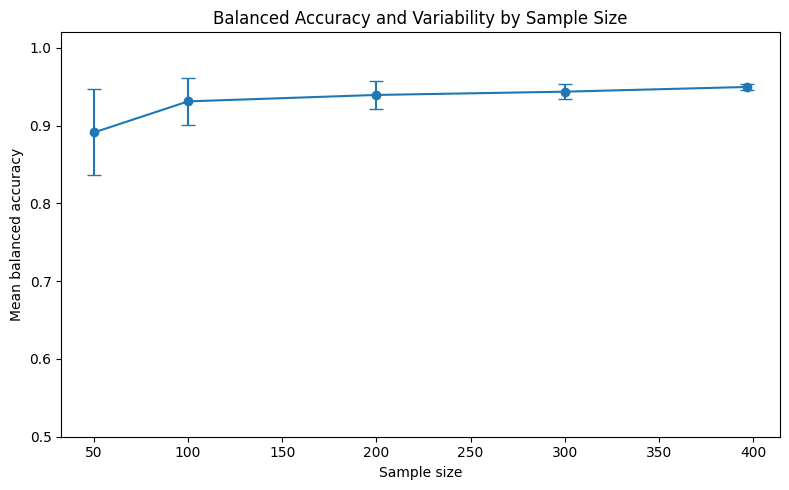

In [47]:
balanced_accuracy_summary = (
    sample_size_results
    .groupby("sample_size")["balanced_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    balanced_accuracy_summary["sample_size"],
    balanced_accuracy_summary["mean"],
    yerr=balanced_accuracy_summary["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean balanced accuracy")
plt.title(
    "Balanced Accuracy and Variability by Sample Size"
)

plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

In [48]:
sample_size_results.to_csv(
    RESULTS_DIR
    / "GSE81538_sample_size_experiment_results.csv",
    index=False
)

sample_size_summary_long.to_csv(
    RESULTS_DIR
    / "GSE81538_sample_size_experiment_summary.csv",
    index=False
)

print("Sample-size experiment results saved.")

Sample-size experiment results saved.


In [49]:
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

sample_sizes = [50, 100, 200, 300, len(y_primary)]
number_of_repetitions = 10
number_of_selected_genes = 1000

selected_gene_sets = []
selection_records = []

for sample_size in sample_sizes:
    print(f"Processing sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        if sample_size == len(y_primary):
            selected_samples = X_primary.index
        else:
            selected_samples, _ = train_test_split(
                X_primary.index,
                train_size=sample_size,
                random_state=repetition,
                stratify=y_primary
            )

        X_subset = X_primary.loc[selected_samples]
        y_subset = y_primary.loc[selected_samples]

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        for fold, (training_positions, _) in enumerate(
            cv.split(X_subset, y_subset),
            start=1
        ):
            X_fold_train = X_subset.iloc[training_positions]
            y_fold_train = y_subset.iloc[training_positions]

            # Remove constant genes using the training fold only.
            variance_filter = VarianceThreshold(threshold=0.0)

            X_variance_filtered = variance_filter.fit_transform(
                X_fold_train
            )

            available_genes = X_fold_train.columns[
                variance_filter.get_support()
            ]

            k = min(
                number_of_selected_genes,
                len(available_genes)
            )

            selector = SelectKBest(
                score_func=f_classif,
                k=k
            )

            selector.fit(
                X_variance_filtered,
                y_fold_train
            )

            selected_genes = available_genes[
                selector.get_support()
            ].tolist()

            set_id = (
                f"n{sample_size}_"
                f"rep{repetition + 1}_"
                f"fold{fold}"
            )

            selected_gene_sets.append({
                "sample_size": sample_size,
                "repetition": repetition + 1,
                "fold": fold,
                "set_id": set_id,
                "genes": set(selected_genes)
            })

            for gene in selected_genes:
                selection_records.append({
                    "sample_size": sample_size,
                    "repetition": repetition + 1,
                    "fold": fold,
                    "set_id": set_id,
                    "gene": gene
                })

selection_records = pd.DataFrame(selection_records)

print("Feature-selection experiment completed.")
print("Number of fitted feature selectors:", len(selected_gene_sets))

Processing sample size: 50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12662] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110:

Processing sample size: 100


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Processing sample size: 200


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Processing sample size: 300
Processing sample size: 397
Feature-selection experiment completed.
Number of fitted feature selectors: 250


In [50]:
jaccard_results = []

for sample_size in sample_sizes:

    sets_for_size = [
        result
        for result in selected_gene_sets
        if result["sample_size"] == sample_size
    ]

    for first, second in combinations(sets_for_size, 2):

        intersection = len(
            first["genes"].intersection(second["genes"])
        )

        union = len(
            first["genes"].union(second["genes"])
        )

        jaccard = intersection / union

        jaccard_results.append({
            "sample_size": sample_size,
            "first_set": first["set_id"],
            "second_set": second["set_id"],
            "jaccard_similarity": jaccard
        })

jaccard_results = pd.DataFrame(jaccard_results)

jaccard_summary = (
    jaccard_results
    .groupby("sample_size")["jaccard_similarity"]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .reset_index()
)

display(jaccard_summary.round(4))

,sample_size,mean,std,min,median,max
0,50,0.2525,0.0789,0.0917,0.2369,0.6051
1,100,0.4169,0.0633,0.2970,0.4045,0.6543
2,200,0.5627,0.0487,0.4378,0.5564,0.7437
3,300,0.6703,0.0289,0.5873,0.6681,0.7652
4,397,0.7712,0.0196,0.7050,0.7715,0.8315


In [51]:
selection_frequency = (
    selection_records
    .groupby(
        ["sample_size", "gene"]
    )
    .size()
    .reset_index(name="times_selected")
)

number_of_runs_per_size = (
    number_of_repetitions * 5
)

selection_frequency["selection_frequency"] = (
    selection_frequency["times_selected"]
    / number_of_runs_per_size
)

top_stable_genes = (
    selection_frequency
    .sort_values(
        ["sample_size", "selection_frequency"],
        ascending=[True, False]
    )
    .groupby("sample_size")
    .head(20)
)

display(top_stable_genes)

,sample_size,gene,times_selected,selection_frequency
1,50,A2ML1,50,1.0
126,50,AGR2,50,1.0
127,50,AGR3,50,1.0
234,50,ANXA9,50,1.0
670,50,C1orf64,50,1.0
768,50,C6orf97,50,1.0
816,50,CA12,50,1.0
1227,50,CMBL,50,1.0
1529,50,DEGS2,50,1.0
1654,50,DSC2,50,1.0


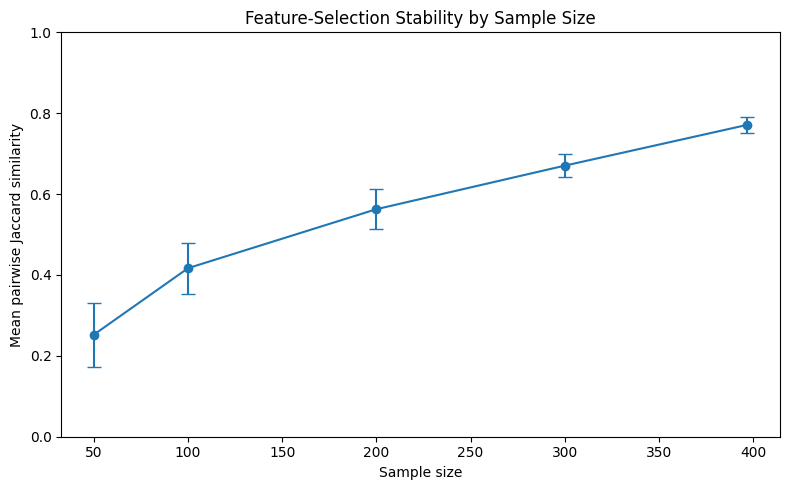

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    jaccard_summary["sample_size"],
    jaccard_summary["mean"],
    yerr=jaccard_summary["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean pairwise Jaccard similarity")
plt.title("Feature-Selection Stability by Sample Size")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [53]:
selection_records.to_csv(
    RESULTS_DIR / "GSE81538_gene_selection_records.csv",
    index=False
)

jaccard_results.to_csv(
    RESULTS_DIR / "GSE81538_feature_jaccard_results.csv",
    index=False
)

jaccard_summary.to_csv(
    RESULTS_DIR / "GSE81538_feature_jaccard_summary.csv",
    index=False
)

selection_frequency.to_csv(
    RESULTS_DIR / "GSE81538_gene_selection_frequencies.csv",
    index=False
)

print("Feature-stability results saved.")

Feature-stability results saved.


In [54]:
top_stable_genes = (
    selection_frequency
    .sort_values(
        ["sample_size", "selection_frequency"],
        ascending=[True, False]
    )
    .groupby("sample_size", group_keys=False)
    .head(20)
)

display(
    top_stable_genes[
        [
            "sample_size",
            "gene",
            "times_selected",
            "selection_frequency"
        ]
    ]
)

,sample_size,gene,times_selected,selection_frequency
1,50,A2ML1,50,1.0
126,50,AGR2,50,1.0
127,50,AGR3,50,1.0
234,50,ANXA9,50,1.0
670,50,C1orf64,50,1.0
768,50,C6orf97,50,1.0
816,50,CA12,50,1.0
1227,50,CMBL,50,1.0
1529,50,DEGS2,50,1.0
1654,50,DSC2,50,1.0


In [55]:
comparison_genes = top_stable_genes[
    top_stable_genes["sample_size"].isin(
        [50, len(y_primary)]
    )
].copy()

display(comparison_genes)

,sample_size,gene,times_selected,selection_frequency
1,50,A2ML1,50,1.0
126,50,AGR2,50,1.0
127,50,AGR3,50,1.0
234,50,ANXA9,50,1.0
670,50,C1orf64,50,1.0
768,50,C6orf97,50,1.0
816,50,CA12,50,1.0
1227,50,CMBL,50,1.0
1529,50,DEGS2,50,1.0
1654,50,DSC2,50,1.0


In [56]:
stable_gene_counts = (
    selection_frequency
    .assign(
        highly_stable=lambda data:
        data["selection_frequency"] >= 0.80
    )
    .groupby("sample_size")["highly_stable"]
    .sum()
    .reset_index(name="genes_selected_in_at_least_80_percent")
)

display(stable_gene_counts)

,sample_size,genes_selected_in_at_least_80_percent
0,50,142
1,100,384
2,200,587
3,300,705
4,397,812


In [57]:
moderately_stable_gene_counts = (
    selection_frequency
    .assign(
        selected_at_least_half=lambda data:
        data["selection_frequency"] >= 0.50
    )
    .groupby("sample_size")["selected_at_least_half"]
    .sum()
    .reset_index(name="genes_selected_in_at_least_50_percent")
)

display(moderately_stable_gene_counts)

,sample_size,genes_selected_in_at_least_50_percent
0,50,547
1,100,793
2,200,892
3,300,943
4,397,969


In [60]:
top_stable_genes.to_csv(
    RESULTS_DIR / "GSE81538_top_stable_genes_by_sample_size.csv",
    index=False
)

stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_highly_stable_gene_counts.csv",
    index=False
)

moderately_stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_moderately_stable_gene_counts.csv",
    index=False
)

In [61]:
stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_genes_selected_at_least_80_percent.csv",
    index=False
)

moderately_stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_genes_selected_at_least_50_percent.csv",
    index=False
)

print("Gene-stability count tables saved.")

Gene-stability count tables saved.


In [62]:
from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

coefficient_records = []

sample_sizes = [50, 100, 200, 300, len(y_primary)]
number_of_repetitions = 10
number_of_selected_genes = 1000

for sample_size in sample_sizes:

    print(f"Processing coefficients for n={sample_size}")

    for repetition in range(number_of_repetitions):

        if sample_size == len(y_primary):
            selected_samples = X_primary.index
        else:
            selected_samples, _ = train_test_split(
                X_primary.index,
                train_size=sample_size,
                random_state=repetition,
                stratify=y_primary
            )

        X_subset = X_primary.loc[selected_samples]
        y_subset = y_primary.loc[selected_samples]

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        for fold, (train_positions, _) in enumerate(
            cv.split(X_subset, y_subset),
            start=1
        ):
            X_fold_train = X_subset.iloc[train_positions]
            y_fold_train = y_subset.iloc[train_positions]

            # 1. Remove constant genes
            variance_filter = VarianceThreshold(threshold=0.0)

            X_variance = variance_filter.fit_transform(
                X_fold_train
            )

            available_genes = X_fold_train.columns[
                variance_filter.get_support()
            ]

            # 2. Select the 1,000 strongest genes
            k = min(
                number_of_selected_genes,
                len(available_genes)
            )

            selector = SelectKBest(
                score_func=f_classif,
                k=k
            )

            X_selected = selector.fit_transform(
                X_variance,
                y_fold_train
            )

            selected_genes = available_genes[
                selector.get_support()
            ]

            # 3. Standardize selected genes
            scaler = StandardScaler()

            X_scaled = scaler.fit_transform(
                X_selected
            )

            # 4. Fit logistic regression
            model = LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )

            model.fit(
                X_scaled,
                y_fold_train
            )

            coefficients = model.coef_[0]

            set_id = (
                f"n{sample_size}_"
                f"rep{repetition + 1}_"
                f"fold{fold}"
            )

            for gene, coefficient in zip(
                selected_genes,
                coefficients
            ):
                coefficient_records.append({
                    "sample_size": sample_size,
                    "repetition": repetition + 1,
                    "fold": fold,
                    "set_id": set_id,
                    "gene": gene,
                    "coefficient": coefficient,
                    "absolute_coefficient": abs(coefficient),
                    "direction": (
                        "ER-positive"
                        if coefficient > 0
                        else "ER-negative"
                    )
                })

coefficient_records = pd.DataFrame(
    coefficient_records
)

print("Coefficient extraction completed.")
print("Rows recorded:", len(coefficient_records))

display(coefficient_records.head())

Processing coefficients for n=50


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing coefficients for n=100


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing coefficients for n=200


...

C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Processing coefficients for n=397


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\linear

Coefficient extraction completed.
Rows recorded: 250000


,sample_size,repetition,fold,set_id,gene,coefficient,absolute_coefficient,direction
0,50,1,1,n50_rep1_fold1,A2ML1,-0.032294,0.032294,ER-negative
1,50,1,1,n50_rep1_fold1,AADAT,-0.021954,0.021954,ER-negative
2,50,1,1,n50_rep1_fold1,AAGAB,0.013011,0.013011,ER-positive
3,50,1,1,n50_rep1_fold1,ABAT,0.006028,0.006028,ER-positive
4,50,1,1,n50_rep1_fold1,ABCC1,-0.039211,0.039211,ER-negative


In [63]:
coefficient_stability = (
    coefficient_records
    .groupby(
        ["sample_size", "gene"]
    )
    .agg(
        times_selected=(
            "coefficient",
            "size"
        ),
        mean_coefficient=(
            "coefficient",
            "mean"
        ),
        coefficient_sd=(
            "coefficient",
            "std"
        ),
        mean_absolute_coefficient=(
            "absolute_coefficient",
            "mean"
        ),
        positive_count=(
            "coefficient",
            lambda values: (values > 0).sum()
        ),
        negative_count=(
            "coefficient",
            lambda values: (values < 0).sum()
        )
    )
    .reset_index()
)

coefficient_stability["selection_frequency"] = (
    coefficient_stability["times_selected"]
    / (number_of_repetitions * 5)
)

coefficient_stability["direction_consistency"] = (
    coefficient_stability[
        ["positive_count", "negative_count"]
    ]
    .max(axis=1)
    / coefficient_stability["times_selected"]
)

coefficient_stability["coefficient_cv"] = (
    coefficient_stability["coefficient_sd"]
    / coefficient_stability[
        "mean_absolute_coefficient"
    ]
)

display(coefficient_stability.head())

,sample_size,gene,times_selected,mean_coefficient,coefficient_sd,mean_absolute_coefficient,positive_count,negative_count,selection_frequency,direction_consistency,coefficient_cv
0,50,A1BG,5,0.025847,0.010957,0.025847,5,0,0.10,1.000000,0.423923
1,50,A2ML1,50,-0.021842,0.014649,0.022709,4,46,1.00,0.920000,0.645066
2,50,AAAS,8,0.020471,0.009783,0.020471,8,0,0.16,1.000000,0.477882
3,50,AADAT,17,-0.011023,0.014624,0.014970,4,13,0.34,0.764706,0.976848
4,50,AAGAB,17,0.007246,0.007607,0.008796,13,4,0.34,0.764706,0.864743


In [64]:
# Focus on genes selected in at least half of the 50 runs
frequently_selected_coefficients = (
    coefficient_stability[
        coefficient_stability["selection_frequency"] >= 0.50
    ]
    .copy()
)

explanation_summary = (
    frequently_selected_coefficients
    .groupby("sample_size")
    .agg(
        frequently_selected_genes=("gene", "count"),
        mean_direction_consistency=(
            "direction_consistency",
            "mean"
        ),
        median_direction_consistency=(
            "direction_consistency",
            "median"
        ),
        genes_with_complete_direction_agreement=(
            "direction_consistency",
            lambda values: (values == 1.0).sum()
        ),
        mean_coefficient_sd=(
            "coefficient_sd",
            "mean"
        )
    )
    .reset_index()
)

display(explanation_summary.round(4))

,sample_size,frequently_selected_genes,mean_direction_consistency,median_direction_consistency,genes_with_complete_direction_agreement,mean_coefficient_sd
0,50,547,0.8326,0.8800,94,0.0135
1,100,793,0.7928,0.8200,123,0.0193
2,200,892,0.8080,0.8289,140,0.0255
3,300,943,0.8375,0.8889,205,0.0270
4,397,969,0.8848,0.9600,352,0.0234


In [65]:
direction_stability_counts = (
    frequently_selected_coefficients
    .assign(
        stable_direction=lambda df:
        df["direction_consistency"] >= 0.90
    )
    .groupby("sample_size")
    .agg(
        frequently_selected_genes=("gene", "count"),
        directionally_stable_genes=(
            "stable_direction",
            "sum"
        )
    )
    .reset_index()
)

direction_stability_counts[
    "percentage_directionally_stable"
] = (
    100
    * direction_stability_counts[
        "directionally_stable_genes"
    ]
    / direction_stability_counts[
        "frequently_selected_genes"
    ]
)

display(direction_stability_counts.round(2))

,sample_size,frequently_selected_genes,directionally_stable_genes,percentage_directionally_stable
0,50,547,242,44.24
1,100,793,269,33.92
2,200,892,337,37.78
3,300,943,460,48.78
4,397,969,601,62.02


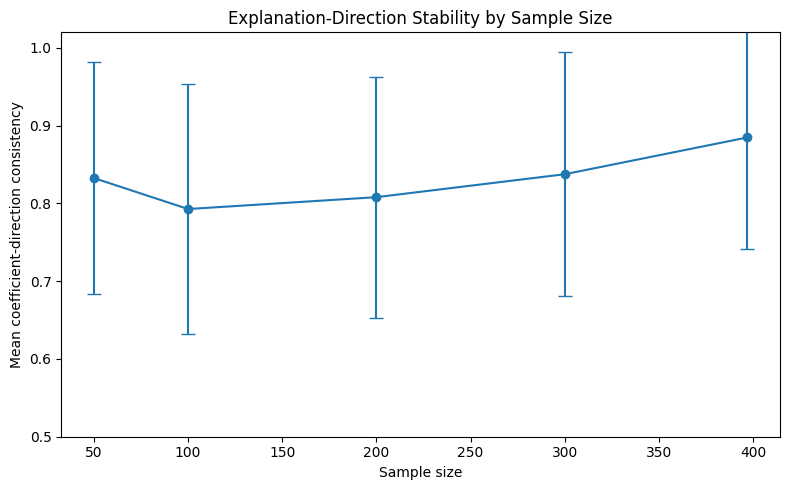

In [66]:
direction_plot_data = (
    frequently_selected_coefficients
    .groupby("sample_size")["direction_consistency"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    direction_plot_data["sample_size"],
    direction_plot_data["mean"],
    yerr=direction_plot_data["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean coefficient-direction consistency")
plt.title("Explanation-Direction Stability by Sample Size")
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

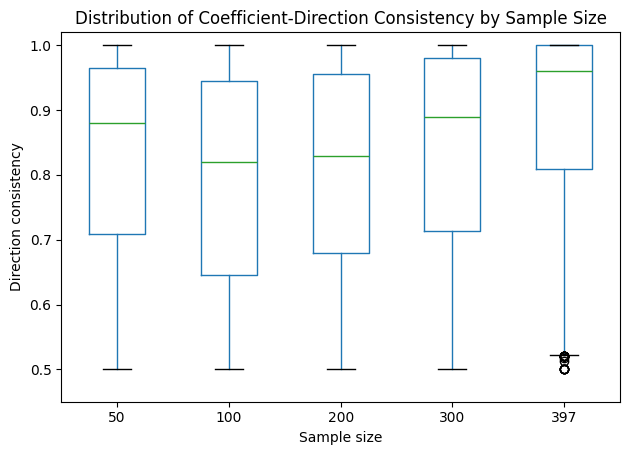

In [67]:
plot_data = frequently_selected_coefficients[
    [
        "sample_size",
        "gene",
        "direction_consistency"
    ]
].copy()

plt.figure(figsize=(9, 6))

plot_data.boxplot(
    column="direction_consistency",
    by="sample_size",
    grid=False
)

plt.suptitle("")
plt.title(
    "Distribution of Coefficient-Direction Consistency "
    "by Sample Size"
)
plt.xlabel("Sample size")
plt.ylabel("Direction consistency")
plt.ylim(0.45, 1.02)
plt.tight_layout()
plt.show()

In [68]:
direction_stability_counts.to_csv(
    RESULTS_DIR
    / "GSE81538_directionally_stable_gene_counts.csv",
    index=False
)

direction_distribution_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_direction_consistency_distribution.csv",
    index=False
)

frequently_selected_coefficients.to_csv(
    RESULTS_DIR
    / "GSE81538_frequently_selected_gene_coefficients.csv",
    index=False
)

print("Explanation-stability results saved.")

NameError: name 'direction_distribution_summary' is not defined

In [69]:
direction_distribution_summary = (
    frequently_selected_coefficients
    .groupby("sample_size")["direction_consistency"]
    .agg(
        gene_count="count",
        mean="mean",
        standard_deviation="std",
        minimum="min",
        q25=lambda values: values.quantile(0.25),
        median="median",
        q75=lambda values: values.quantile(0.75),
        maximum="max"
    )
    .reset_index()
)

display(direction_distribution_summary.round(4))

,sample_size,gene_count,mean,standard_deviation,minimum,q25,median,q75,maximum
0,50,547,0.8326,0.1492,0.5,0.7090,0.8800,0.9643,1.0
1,100,793,0.7928,0.1612,0.5,0.6452,0.8200,0.9444,1.0
2,200,892,0.8080,0.1551,0.5,0.6800,0.8289,0.9560,1.0
3,300,943,0.8375,0.1570,0.5,0.7127,0.8889,0.9800,1.0
4,397,969,0.8848,0.1436,0.5,0.8085,0.9600,1.0000,1.0


In [70]:
print("direction_stability_counts exists:",
      "direction_stability_counts" in globals())

print("direction_distribution_summary exists:",
      "direction_distribution_summary" in globals())

print("frequently_selected_coefficients exists:",
      "frequently_selected_coefficients" in globals())

direction_stability_counts exists: True
direction_distribution_summary exists: True
frequently_selected_coefficients exists: True


In [71]:
direction_stability_counts.to_csv(
    RESULTS_DIR
    / "GSE81538_directionally_stable_gene_counts.csv",
    index=False
)

direction_distribution_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_direction_consistency_distribution.csv",
    index=False
)

frequently_selected_coefficients.to_csv(
    RESULTS_DIR
    / "GSE81538_frequently_selected_gene_coefficients.csv",
    index=False
)

print("Explanation-stability results saved.")

Explanation-stability results saved.


In [72]:
full_sample_coefficients = (
    frequently_selected_coefficients[
        frequently_selected_coefficients["sample_size"] == 397
    ]
    .copy()
)

stable_full_sample_genes = (
    full_sample_coefficients[
        full_sample_coefficients["direction_consistency"] >= 0.90
    ]
    .sort_values(
        [
            "selection_frequency",
            "direction_consistency",
            "mean_absolute_coefficient"
        ],
        ascending=False
    )
)

unstable_full_sample_genes = (
    full_sample_coefficients[
        full_sample_coefficients["direction_consistency"] < 0.70
    ]
    .sort_values(
        [
            "direction_consistency",
            "selection_frequency"
        ],
        ascending=[True, False]
    )
)

print(
    "Stable genes at n=397:",
    len(stable_full_sample_genes)
)

print(
    "Unstable genes at n=397:",
    len(unstable_full_sample_genes)
)

display(
    stable_full_sample_genes[
        [
            "gene",
            "selection_frequency",
            "mean_coefficient",
            "coefficient_sd",
            "direction_consistency",
            "mean_absolute_coefficient"
        ]
    ].head(25).round(4)
)

display(
    unstable_full_sample_genes[
        [
            "gene",
            "selection_frequency",
            "mean_coefficient",
            "coefficient_sd",
            "direction_consistency",
            "mean_absolute_coefficient"
        ]
    ].head(25).round(4)
)

Stable genes at n=397: 601
Unstable genes at n=397: 141


,gene,selection_frequency,mean_coefficient,coefficient_sd,direction_consistency,mean_absolute_coefficient
15427,KBTBD12,1.0,-0.1844,0.0283,1.0,0.1844
15233,FBN3,1.0,-0.1712,0.0328,1.0,0.1712
16047,SLC4A8,1.0,0.1645,0.0189,1.0,0.1645
16076,SOX11,1.0,-0.1568,0.0329,1.0,0.1568
14843,C11orf86,1.0,-0.1556,0.0274,1.0,0.1556
16045,SLC44A4,1.0,0.1443,0.0234,1.0,0.1443
15682,NKX1-2,1.0,-0.1429,0.0366,1.0,0.1429
15155,EID1,1.0,0.1410,0.0305,1.0,0.1410
14714,ACE2,1.0,-0.1374,0.0267,1.0,0.1374
15832,PRDM13,1.0,-0.1371,0.0212,1.0,0.1371


,gene,selection_frequency,mean_coefficient,coefficient_sd,direction_consistency,mean_absolute_coefficient
15902,RASGEF1B,1.00,-0.0012,0.0287,0.5000,0.0214
15936,RNASE4,1.00,-0.0012,0.0255,0.5000,0.0210
16314,ZIC1,1.00,0.0006,0.0268,0.5000,0.0207
15821,PPARGC1B,0.88,-0.0042,0.0226,0.5000,0.0193
16201,TMEM26,0.60,0.0009,0.0158,0.5000,0.0125
15854,PRSS3,0.56,-0.0095,0.0450,0.5000,0.0353
14968,CDC45,0.78,0.0003,0.0113,0.5128,0.0092
14986,CEACAM19,0.58,0.0024,0.0355,0.5172,0.0302
14772,ARL3,1.00,-0.0004,0.0157,0.5200,0.0122
14948,CCDC96,1.00,-0.0001,0.0132,0.5200,0.0102


In [73]:
stable_full_sample_genes.to_csv(
    RESULTS_DIR
    / "GSE81538_stable_explanatory_genes_n397.csv",
    index=False
)

unstable_full_sample_genes.to_csv(
    RESULTS_DIR
    / "GSE81538_unstable_explanatory_genes_n397.csv",
    index=False
)

print("Stable and unstable explanatory gene lists saved.")

Stable and unstable explanatory gene lists saved.
